In [ ]:
from data_utils import (
    save_i24_hourly_trajectory_batches,
    sweep_i24_flow_density_matrices,
)
import pandas as pd
import numpy as np

day_windows = {
    # "nov21": pd.date_range("2022-11-21 12:00:00", "2022-11-21 15:00:00", freq="1h"),
    # "nov23": pd.date_range("2022-11-23 12:00:00", "2022-11-23 15:00:00", freq="1h"),
    # "nov30": pd.date_range("2022-11-30 12:00:00", "2022-11-30 15:00:00", freq="1h"),
    "nov29": pd.date_range("2022-11-29 12:00:00", "2022-11-29 15:00:00", freq="1h"),

}

trajectory_manifest = save_i24_hourly_trajectory_batches(
    day_windows=day_windows,
    batch_hours=1,
    direction_str="west",
    data_dir="data/i24",
    output_dir="data/i24/parsed_trajectories",
)

matrix_manifest = sweep_i24_flow_density_matrices(
    trajectory_manifest=trajectory_manifest,
    x_increases_in_travel_direction=False,
    time_intervals=[10/60, 30/60, 1, 5],
    space_intervals=[200, 400, 600, 800],
    output_dir="data/i24/matrix_sweeps",
)

Loaded 172559 westbound trajectories.
['trajectory_id', 'timestamp', 'x_position', 'y_position']
          trajectory_id                     timestamp    x_position  \
0                     0 2022-11-21 12:00:00.400000095  99568.085938   
1                     0 2022-11-21 12:00:00.440000057  99567.015625   
2                     0 2022-11-21 12:00:00.480000019  99565.937500   
3                     0 2022-11-21 12:00:00.520000219  99564.875000   
4                     0 2022-11-21 12:00:00.560000181  99563.804688   
...                 ...                           ...           ...   
63017678         172558 2022-11-21 12:59:59.820000410  99046.875000   
63017679         172558 2022-11-21 12:59:59.860000372  99046.687500   
63017680         172558 2022-11-21 12:59:59.900000334  99046.507812   
63017681         172558 2022-11-21 12:59:59.940000296  99046.304688   
63017682         172558 2022-11-21 12:59:59.980000257  99046.117188   

          y_position  
0           5.817278  
1   

In [1]:
from data_utils import repair_i24_daily_combined_matrices

repaired_manifest = repair_i24_daily_combined_matrices(
    input_dir="data/i24/matrix_sweeps/daily_combined",
    output_dir="data/i24/matrix_sweeps/daily_combined_repaired",
)
repaired_manifest.head(10)

,source_path,output_path,metric,dx_meters,original_shape,repaired_shape,removed_rows,interpolated_rows,trimmed_initial_time_minutes,trimmed_initial_columns
0,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,density,200,33x1345,32x1165,0,12,30.0,180
1,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,flow,200,33x1345,32x1165,0,12,30.0,180
2,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,density,400,17x1345,16x1165,0,6,30.0,180
3,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,flow,400,17x1345,16x1165,0,6,30.0,180
4,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,density,600,11x1345,10x1165,0,,30.0,180
5,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,flow,600,11x1345,10x1165,0,,30.0,180
6,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,density,800,9x1345,8x1165,0,,30.0,180
7,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,flow,800,9x1345,8x1165,0,,30.0,180
8,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,density,200,33x223,32x193,0,12,30.0,30
9,data/i24/matrix_sweeps/daily_combined/nov21_we...,data/i24/matrix_sweeps/daily_combined_repaired...,flow,200,33x223,32x193,0,12,30.0,30


num time bins: 1165
num space bins: 16


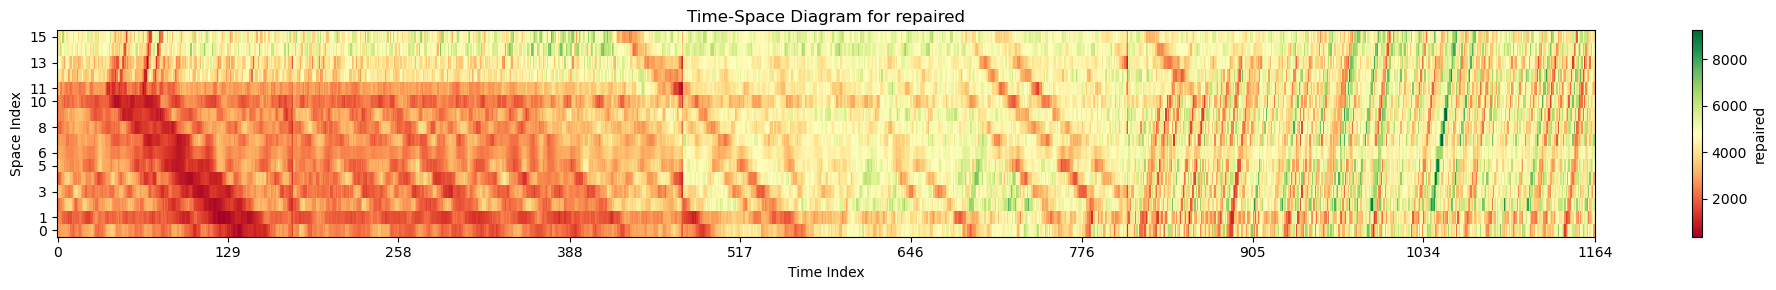

In [ ]:
from data_utils import plot_matrix
import numpy as np
matrix = np.load("data/i24/matrix_sweeps/daily_combined_repaired/nov21_west_1200_1600_dt_10s_dx_400m_flow.npy")
plot_matrix(matrix, "repaired")
# time now starts at 6:30 AM. The first space bin is chopped off. space bin with pole 25 is interpolated

In [3]:
from data_utils import print_i24_space_bin_miles
manifest = print_i24_space_bin_miles("data/i24/matrix_sweeps/daily_combined_repaired")


dx = 200 m (0.124275 mi), bins = 32
edges_miles =
[58.8, 58.924275, 59.048549, 59.172824, 59.297098, 59.421373, 59.545647, 59.669922, 59.794196, 59.918471, 60.042745, 60.16702, 60.291295, 60.415569, 60.539844, 60.664118, 60.788393, 60.912667, 61.036942, 61.161216, 61.285491, 61.409765, 61.53404, 61.658315, 61.782589, 61.906864, 62.031138, 62.155413, 62.279687, 62.403962, 62.528236, 62.652511, 62.776786]
centers_miles =
[58.862137, 58.986412, 59.110686, 59.234961, 59.359235, 59.48351, 59.607785, 59.732059, 59.856334, 59.980608, 60.104883, 60.229157, 60.353432, 60.477706, 60.601981, 60.726255, 60.85053, 60.974805, 61.099079, 61.223354, 61.347628, 61.471903, 61.596177, 61.720452, 61.844726, 61.969001, 62.093276, 62.21755, 62.341825, 62.466099, 62.590374, 62.714648]

dx = 400 m (0.248549 mi), bins = 16
edges_miles =
[58.8, 59.048549, 59.297098, 59.545647, 59.794196, 60.042745, 60.291295, 60.539844, 60.788393, 61.036942, 61.285491, 61.53404, 61.782589, 62.031138, 62.279687, 62.528236, 62.7

In [1]:
from data_utils import save_i24_lane_and_ramp_mappings

manifest = save_i24_lane_and_ramp_mappings()
print(manifest)

Ramp bin 0 [62.6525109672288, 62.77678551455876): 0 on-ramps, 0 off-ramps
Ramp bin 1 [62.52823641989884, 62.6525109672288): 0 on-ramps, 0 off-ramps
Ramp bin 2 [62.40396187256888, 62.52823641989884): 0 on-ramps, 0 off-ramps
Ramp bin 3 [62.27968732523892, 62.40396187256888): 0 on-ramps, 0 off-ramps
Ramp bin 4 [62.15541277790896, 62.27968732523892): 1 on-ramps, 0 off-ramps
Ramp bin 5 [62.03113823057899, 62.15541277790896): 0 on-ramps, 0 off-ramps
Ramp bin 6 [61.90686368324903, 62.03113823057899): 0 on-ramps, 0 off-ramps
Ramp bin 7 [61.78258913591907, 61.90686368324903): 0 on-ramps, 0 off-ramps
Ramp bin 8 [61.65831458858911, 61.78258913591907): 0 on-ramps, 0 off-ramps
Ramp bin 9 [61.534040041259146, 61.65831458858911): 0 on-ramps, 0 off-ramps
Ramp bin 10 [61.409765493929186, 61.534040041259146): 0 on-ramps, 0 off-ramps
Ramp bin 11 [61.285490946599225, 61.409765493929186): 0 on-ramps, 0 off-ramps
Ramp bin 12 [61.161216399269264, 61.285490946599225): 0 on-ramps, 0 off-ramps
Ramp bin 13 [61.0

In [3]:
import numpy as np
lanes = np.load("data/i24/segment_mappings/lane_mapping_dx_200m.npy")
lanes

array([4.        , 4.        , 4.        , 4.        , 4.21951759,
       5.        , 5.        , 5.        , 4.54670702, 4.        ,
       4.        , 4.        , 4.        , 4.        , 4.        ,
       4.        , 4.        , 4.        , 4.        , 4.40389115,
       4.        , 4.        , 4.        , 4.85516794, 5.        ,
       4.64586553, 4.        , 4.        , 4.        , 4.        ,
       4.        , 4.        ])

In [1]:
from data_utils import (
    save_repaired_i24_velocity_matrices,
    save_repaired_i24_flow_per_lane_matrices,
)

velocity_manifest = save_repaired_i24_velocity_matrices(
    input_dir="data/i24/matrix_sweeps/daily_combined_repaired",
)

flow_per_lane_manifest = save_repaired_i24_flow_per_lane_matrices(
    input_dir="data/i24/matrix_sweeps/daily_combined_repaired",
    lane_mapping_dir="data/i24/segment_mappings",
)

velocity_manifest.head(), flow_per_lane_manifest.head()

(                                           flow_path  \
 0  data/i24/matrix_sweeps/daily_combined_repaired...   
 1  data/i24/matrix_sweeps/daily_combined_repaired...   
 2  data/i24/matrix_sweeps/daily_combined_repaired...   
 3  data/i24/matrix_sweeps/daily_combined_repaired...   
 4  data/i24/matrix_sweeps/daily_combined_repaired...   
 
                                         density_path  \
 0  data/i24/matrix_sweeps/daily_combined_repaired...   
 1  data/i24/matrix_sweeps/daily_combined_repaired...   
 2  data/i24/matrix_sweeps/daily_combined_repaired...   
 3  data/i24/matrix_sweeps/daily_combined_repaired...   
 4  data/i24/matrix_sweeps/daily_combined_repaired...   
 
                                        velocity_path  dx_meters    dt    shape  
 0  data/i24/matrix_sweeps/daily_combined_repaired...        200   10s  32x1165  
 1  data/i24/matrix_sweeps/daily_combined_repaired...        400   10s  16x1165  
 2  data/i24/matrix_sweeps/daily_combined_repaired...        600  

num time bins: 1165
num space bins: 32


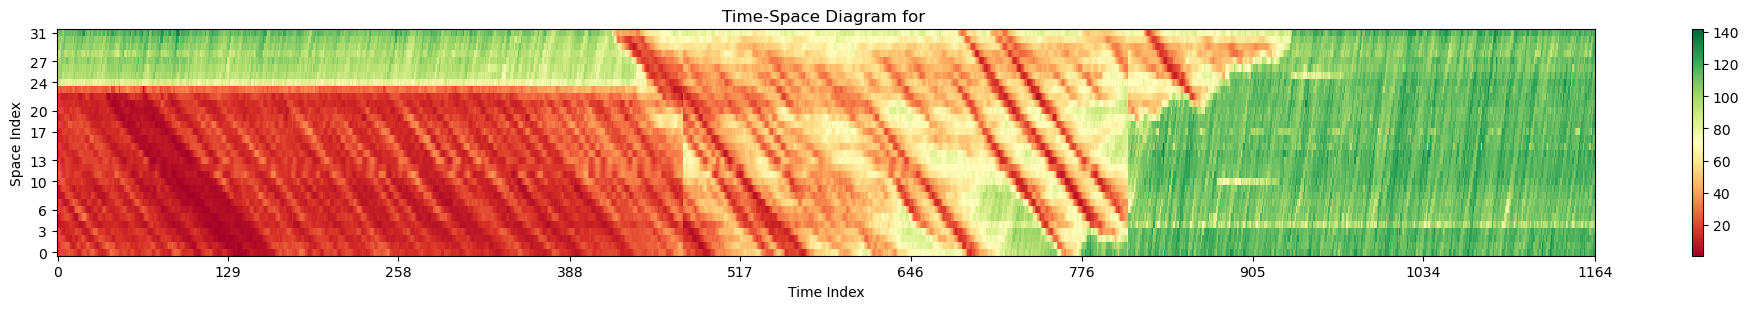

In [10]:
from data_utils import plot_matrix
import numpy as np
matrix = np.load("data/i24/matrix_sweeps/daily_combined_repaired/nov21_west_1200_1600_dt_10s_dx_200m_velocity.npy")
plot_matrix(matrix, "")